In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


In [2]:
from evoaudio.sample_library import SampleLibrary
sample_lib = SampleLibrary()

Loading samples:   0%|          | 0/6826 [00:00<?, ?it/s]

In [3]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from evoaudio.sample_library import SampleLibrary
from evoaudio.chord_metrics import chord_metrics
from evoaudio.instrument_metric import avg_hausdorff_instruments, hausdorff_instruments_full_piece_GD_IGD
from evoaudio.jaccard import jaccard_error_GD_IGD, extract_samples
from evoaudio.jaccard import class_mode

In [4]:
base_path = "experiments/moea/tiny_aam/ea"

In [5]:
def remove_empty_onsets(annotations: dict[int, list[tuple]]):
    return {
        t: ann
        for t, ann in annotations.items()
        if len(ann) > 0
    }

In [6]:
import itertools
import numpy as np

def individual_distance(a, b):
    extracted_features_a = set(extract_samples(a))
    extracted_features_b = set(extract_samples(b))
    
    union = extracted_features_a | extracted_features_b
    intersection = extracted_features_a & extracted_features_b
    
    if len(union) == 0:
        return 0.0
    
    jaccard_similarity = len(intersection) / len(union)
    jaccard_distance = 1 - jaccard_similarity
    
    return jaccard_distance

def population_diversity(pop):
    individuals = pop.individuals 
    
    if len(individuals) < 2:
        return 0.0
    
    distances = []
    
    for a, b in itertools.combinations(individuals, 2):
        d = individual_distance(a, b)
        distances.append(d)
    
    return np.mean(distances)

In [7]:
all_files = [
    f for f in os.listdir(base_path)
    if f.endswith("_300_populations.pkl")
]

print(f"Found {len(all_files)} population files.")

rows = []

# -------------------------------------------------
# Process each file
# -------------------------------------------------

for file in all_files:
    print("analyzing file:", file)
    full_path = os.path.join(base_path, file)
    
    run_id, rest = file.split("__", 1)
    obj_string = rest.replace("_300_populations.pkl", "")
    run_id = int(run_id)
    
    with open(full_path, "rb") as f:
        result_logs = pickle.load(f)
    
    for name, annotation_dict, onsets, target_sr, pop in result_logs:
    
        pop._expand(sample_lib)

        diversity = population_diversity(pop)

        rows.append({
            "run_id": run_id,
            "objectives": obj_string,
            "num_objectives": len(obj_string.split("__")),
            "piece": name,
            "diversity": diversity
        })

# -------------------------------------------------
# Final DataFrame
# -------------------------------------------------

df = pd.DataFrame(rows)

print(df.head())
print("\nShape:", df.shape)

df

Found 20 population files.
analyzing file: 0__stft_js_divergence_300_populations.pkl
analyzing file: 0__stft_kl_divergence_300_populations.pkl
analyzing file: 1__stft_js_divergence_300_populations.pkl
analyzing file: 1__stft_kl_divergence_300_populations.pkl
analyzing file: 2__stft_js_divergence_300_populations.pkl
analyzing file: 2__stft_kl_divergence_300_populations.pkl
analyzing file: 3__stft_js_divergence_300_populations.pkl
analyzing file: 3__stft_kl_divergence_300_populations.pkl
analyzing file: 4__stft_js_divergence_300_populations.pkl
analyzing file: 4__stft_kl_divergence_300_populations.pkl
analyzing file: 5__stft_js_divergence_300_populations.pkl
analyzing file: 5__stft_kl_divergence_300_populations.pkl
analyzing file: 6__stft_js_divergence_300_populations.pkl
analyzing file: 6__stft_kl_divergence_300_populations.pkl
analyzing file: 7__stft_js_divergence_300_populations.pkl
analyzing file: 7__stft_kl_divergence_300_populations.pkl
analyzing file: 8__stft_js_divergence_300_pop

,run_id,objectives,num_objectives,piece,diversity
0,0,stft_js_divergence,1,0001,0.880011
1,0,stft_js_divergence,1,3000,0.888806
2,0,stft_js_divergence,1,2462,0.869834
3,0,stft_js_divergence,1,2828,0.911201
4,0,stft_js_divergence,1,0192,0.855407
...,...,...,...,...,...
395,9,stft_kl_divergence,1,1014,0.791379
396,9,stft_kl_divergence,1,2602,0.841823
397,9,stft_kl_divergence,1,2990,0.768184
398,9,stft_kl_divergence,1,0620,0.917817


In [8]:
df.to_csv(os.path.join(base_path, "diversity_EA.csv"), index=False)

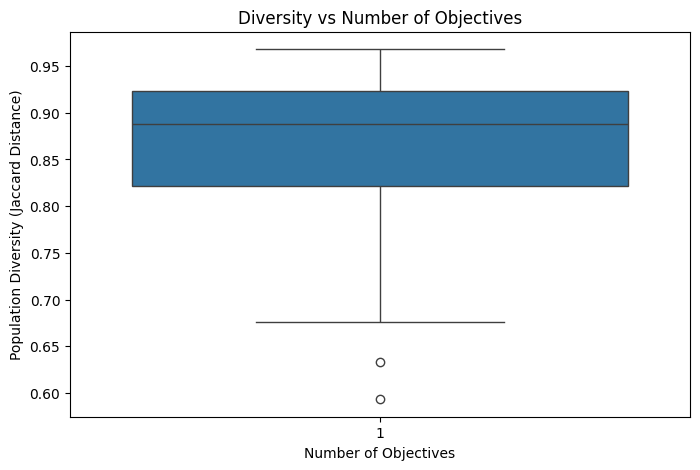

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="num_objectives",
    y="diversity"
)

plt.xlabel("Number of Objectives")
plt.ylabel("Population Diversity (Jaccard Distance)")
plt.title("Diversity vs Number of Objectives")

plt.show()

In [9]:
import re
import pandas as pd
from evoaudio.population import Population

results = []
BASE_FOLDER = "./experiments/tiny_aam/"
folder_pattern = re.compile(r"stft_js_divergence_(\d+)$") 

for folder in os.listdir(BASE_FOLDER):
    folder_path = os.path.join(BASE_FOLDER, folder)
    if not os.path.isdir(folder_path):
        continue

    match = folder_pattern.match(folder)
    if not match:
        print(f"⚠️ Skipping {folder} — doesn’t match expected pattern.")
        continue

    
    index = match.groups()
    base_name = "stft_js_diveregence"

    # Split base_name into feature + distance (split at first underscore)
    if "_" in base_name:
        feature, distance = base_name.split("_", 1)
    else:
        feature, distance = base_name, "unknown"

    print(f"📂 Analyzing: Feature={feature}, Distance={distance}, Piece={index}")

    # --- Process all files inside ---
    for filename in os.listdir(folder_path):
        if filename.endswith(".pkl") and not filename.endswith("_annotations.pkl"):
            name = filename.replace(".pkl", "")
            result_path = os.path.join(folder_path, f"{name}.pkl")
            annotation_path = os.path.join(folder_path, f"{name}_annotations.pkl")

            if not os.path.exists(annotation_path):
                print(f"⚠️ Missing annotations for {name}, skipping.")
                continue

            # --- Load population ---
            pop = Population.from_file(result_path, expand=True, sample_lib=sample_lib)

            # --- Load annotations ---
            with open(annotation_path, "rb") as f:
                annotation_data = pickle.load(f)
            annotations = annotation_data["annotations"]

            # --- Align and filter ---
            annotation_items = list(annotations.items())
            archive_items = list(pop.archive.items())
            min_len = min(len(annotation_items), len(archive_items))

            aligned_annotations = {
                i: annotation_items[i][1]
                for i in range(min_len)
                if len(annotation_items[i][1]) > 0
            }
            aligned_archive = {
                i: archive_items[i][1]
                for i in range(min_len)
                if len(annotation_items[i][1]) > 0
            }

            pop.archive = aligned_archive
            annotations = aligned_annotations
            
            #instrument_err = hausdorff_instruments_full_piece_GD_IGD(pop, annotations, algorithm="EA")
            jaccard_err = jaccard_error_GD_IGD(pop, annotations)
            
            results.append({
                "piece": index,
                "file": name,
                #"instrument_error": instrument_err,
                "Jaccard": jaccard_err
            })
            print("Done: ", filename)
            
df = pd.DataFrame(results)

⚠️ Skipping 300_1_10000_0.05_5_10_1_20_0.9954_15_10_1sec_convlog — doesn’t match expected pattern.
⚠️ Skipping 300_1_10000_0.05_5_10_1_20_0.9954_15_10_1sec_repeat — doesn’t match expected pattern.
⚠️ Skipping 300_1_10000_0.05_5_10_1_20_0.9954_15_20_1sec_preprocess — doesn’t match expected pattern.
⚠️ Skipping 300_1_10000_0.05_5_5_1_8_0.9954_15_20_1sec_preprocess — doesn’t match expected pattern.
⚠️ Skipping all_random_0 — doesn’t match expected pattern.
⚠️ Skipping all_random_1 — doesn’t match expected pattern.
⚠️ Skipping all_random_10 — doesn’t match expected pattern.
⚠️ Skipping all_random_11 — doesn’t match expected pattern.
⚠️ Skipping all_random_12 — doesn’t match expected pattern.
⚠️ Skipping all_random_13 — doesn’t match expected pattern.
⚠️ Skipping all_random_14 — doesn’t match expected pattern.
⚠️ Skipping all_random_15 — doesn’t match expected pattern.
⚠️ Skipping all_random_16 — doesn’t match expected pattern.
⚠️ Skipping all_random_17 — doesn’t match expected pattern.
⚠️ 

In [10]:
df

,piece,file,Jaccard
0,"(0,)",3000,"(0.9788809523809525, 0.9224712279590329)"
1,"(1,)",2828,"(0.8510555555555556, 0.9179984130771532)"
2,"(10,)",2841,"(0.4783333333333332, 0.8757843137254903)"
3,"(11,)",0758,"(0.9664603174603176, 0.905141344599176)"
4,"(12,)",0192,"(0.9577380952380953, 0.8909489390994493)"
5,"(13,)",2395,"(0.7720158730158729, 0.941405433646813)"
6,"(14,)",2269,"(0.9635108225108227, 0.9578633557800226)"
7,"(15,)",1014,"(0.9813134920634919, 0.8779747031246282)"
8,"(16,)",0080,"(0.893, 0.8687894434882386)"
9,"(17,)",0989,"(0.8970378787878788, 0.8590250706031152)"


In [11]:
df.to_csv(os.path.join(BASE_FOLDER, "Jaccard_GD_IGD_stft_js_divergence_aam_final_population.csv"), index=False)